
     ADVANCED CAR PRICE PREDICTION - HIGH PERFORMANCE LINEAR REGRESSION

✓ Libraries imported successfully!
✓ Random seed: 42
✓ Target R² Score: 0.6 - 0.85

SECTION 2: DATA LOADING

✅ Dataset loaded successfully!
📊 Shape: 188,533 rows × 13 columns
💾 Memory usage: 103.92 MB

🔍 Sample Data:


,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200.0
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999.0
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900.0
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000.0
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500.0



🧾 Dataset Info:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            188533 non-null  int32  
 1   brand         188533 non-null  object 
 2   model         188533 non-null  object 
 3   model_year    188533 non-null  int64  
 4   milage        188533 non-null  int64  
 5   fuel_type     183450 non-null  object 
 6   engine        188533 non-null  object 
 7   transmission  188533 non-null  object 
 8   ext_col       188533 non-null  object 
 9   int_col       188533 non-null  object 
 10  accident      186081 non-null  object 
 11  clean_title   167114 non-null  object 
 12  price         188533 non-null  float32
dtypes: float32(1), int32(1), int64(2), object(9)
memory usage: 17.3+ MB

❗ Missing Values Summary:
clean_title    21419
fuel_type 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,188533.00,nan,nan,nan,94266.00,54424.93,0.00,47133.00,94266.00,141399.00,188532.00
brand,188533,57.00,Ford,23088,nan,nan,nan,nan,nan,nan,nan
model,188533,1897.00,F-150 XLT,2945,nan,nan,nan,nan,nan,nan,nan
model_year,188533.00,nan,nan,nan,2015.83,5.66,1974.00,2013.00,2017.00,2020.00,2024.00
milage,188533.00,nan,nan,nan,65705.30,49798.16,100.00,24115.00,57785.00,95400.00,405000.00
fuel_type,183450,7.00,Gasoline,165940,nan,nan,nan,nan,nan,nan,nan
engine,188533,1117.00,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,3462,nan,nan,nan,nan,nan,nan,nan
transmission,188533,52.00,A/T,49904,nan,nan,nan,nan,nan,nan,nan
ext_col,188533,319.00,Black,48658,nan,nan,nan,nan,nan,nan,nan
int_col,188533,156.00,Black,107674,nan,nan,nan,nan,nan,nan,nan



✅ SECTION 2 COMPLETED SUCCESSFULLY

SECTION 3: DATA ANALYSIS & DIAGNOSTICS

📊 Feature Types:
   • Numeric: 2
   • Categorical: 9

🎯 Target Variable (Price) Analysis:
   • Mean: $43,878.02
   • Median: $30,825.00
   • Std: $78,815.83
   • Skewness: 20.2685 (Right-skewed - LOG TRANSFORM NEEDED)
   • Range: $2,000.00 - $2,954,083.00



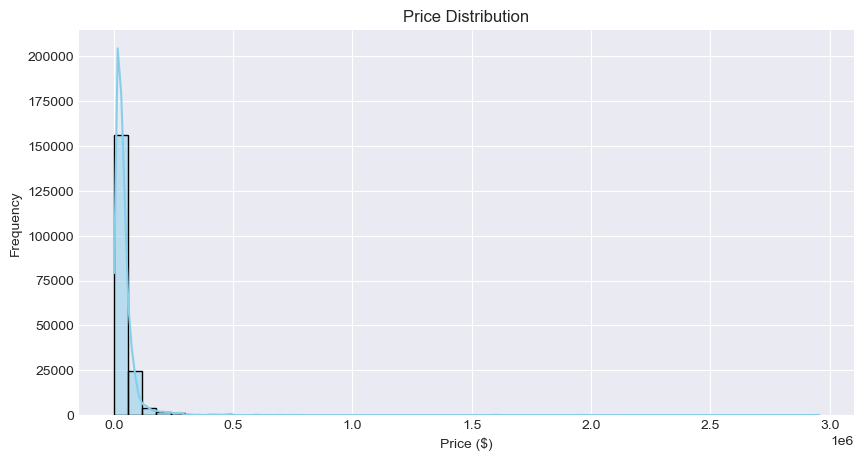

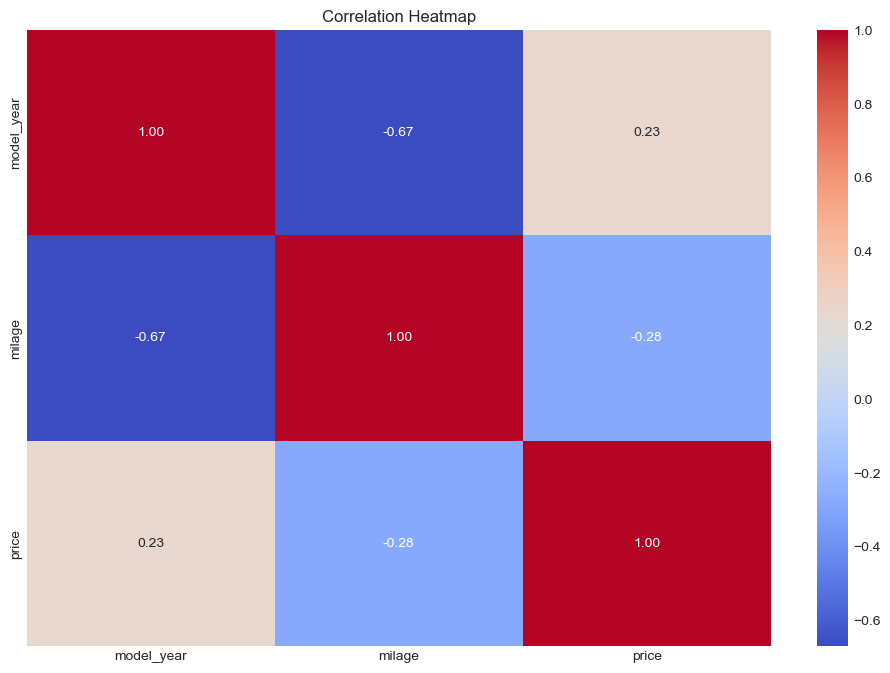

SECTION 4: DATA PREPROCESSING

✅ Data copied to df_processed for preprocessing.

🔧 Step 1: Handling Missing Values...
   • fuel_type                 → Filled with mode ('Gasoline')
   • accident                  → Filled with mode ('None reported')
   • clean_title               → Filled with mode ('Yes')
✅ All missing values handled!

🎯 Step 2: Smart Categorical Feature Capping...
   🔹 brand                    :    57 →    51 categories (Top + Other)
   🔸 model                    :  1897 →   101 categories (Top + Other)
   ✓ fuel_type                :     7 categories (No change)
   🔸 engine                   :  1117 →   101 categories (Top + Other)
   🔹 transmission             :    52 →    51 categories (Top + Other)
   🔹 ext_col                  :   319 →    51 categories (Top + Other)
   🔹 int_col                  :   156 →    51 categories (Top + Other)
   ✓ accident                 :     2 categories (No change)
   ✓ clean_title              :     1 categories (No change)

✅ Cat

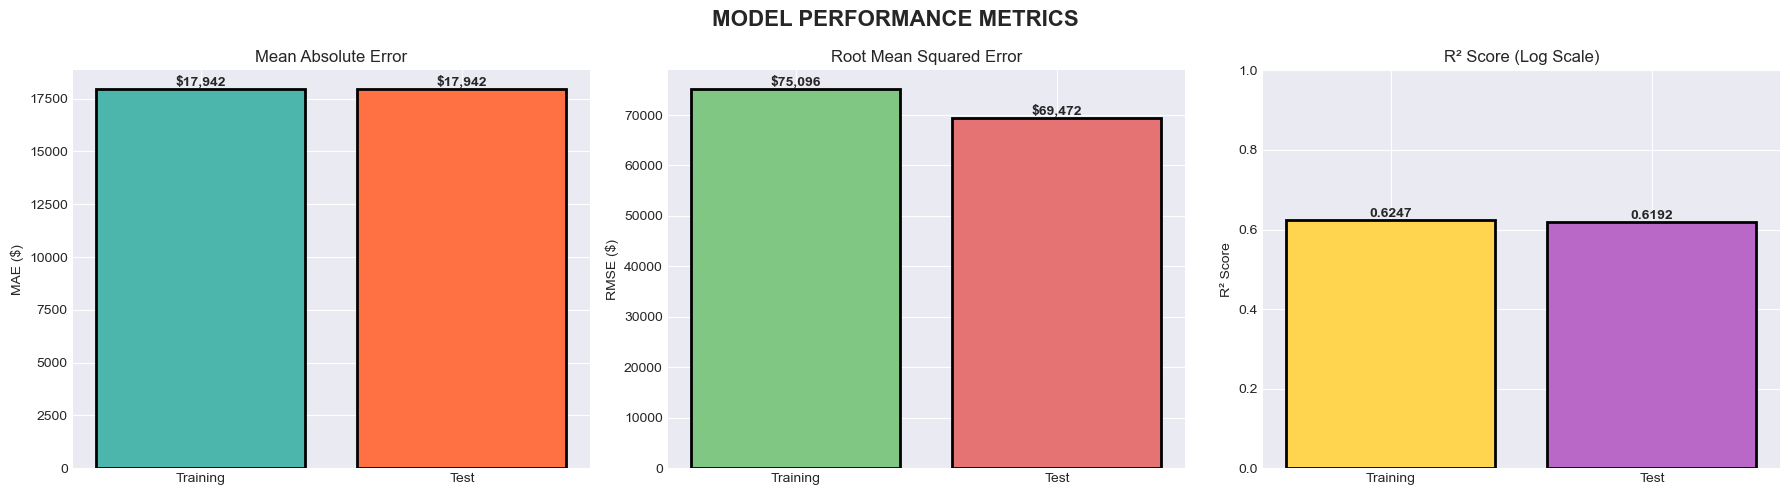

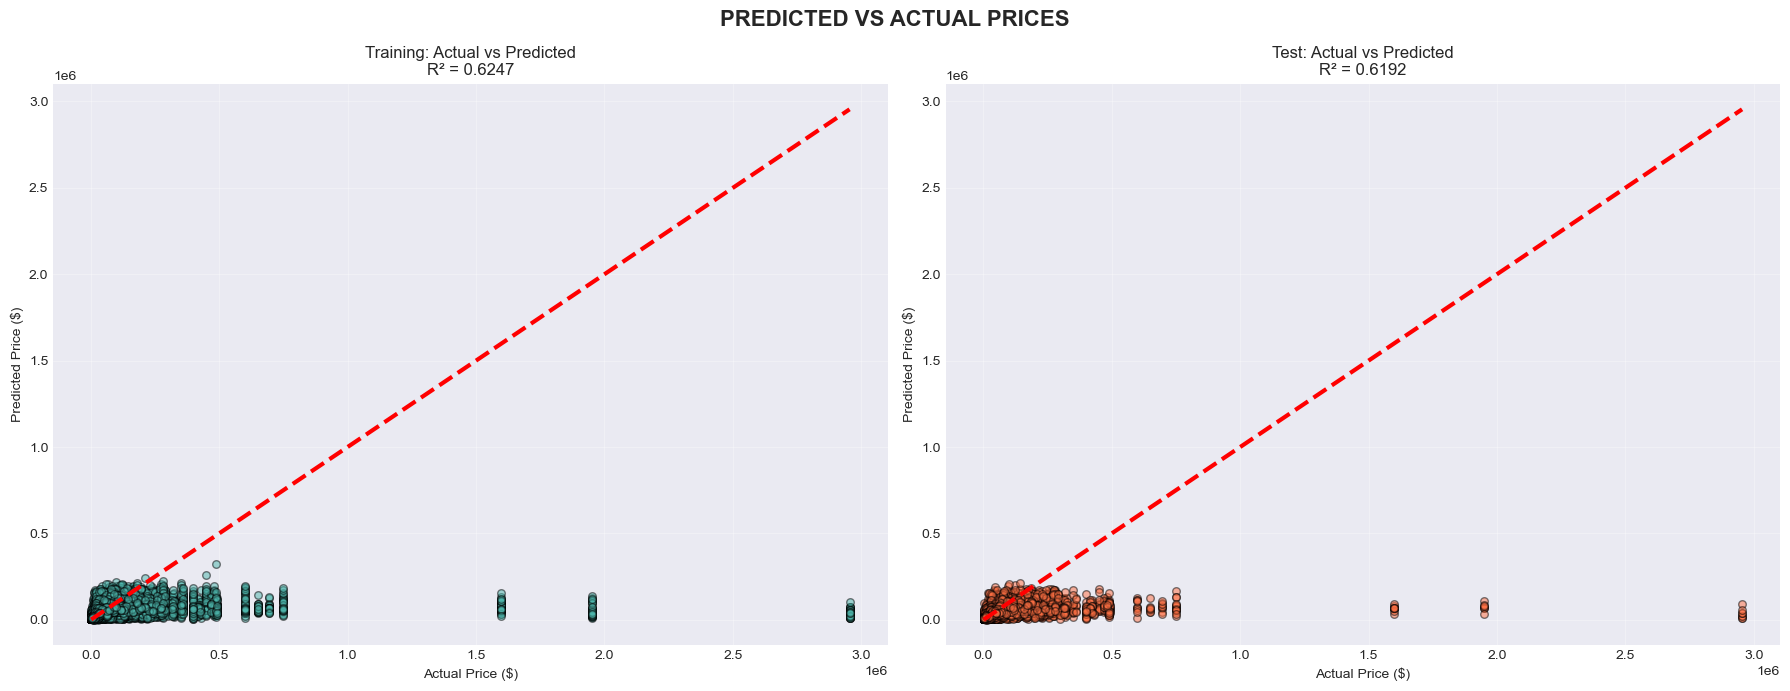

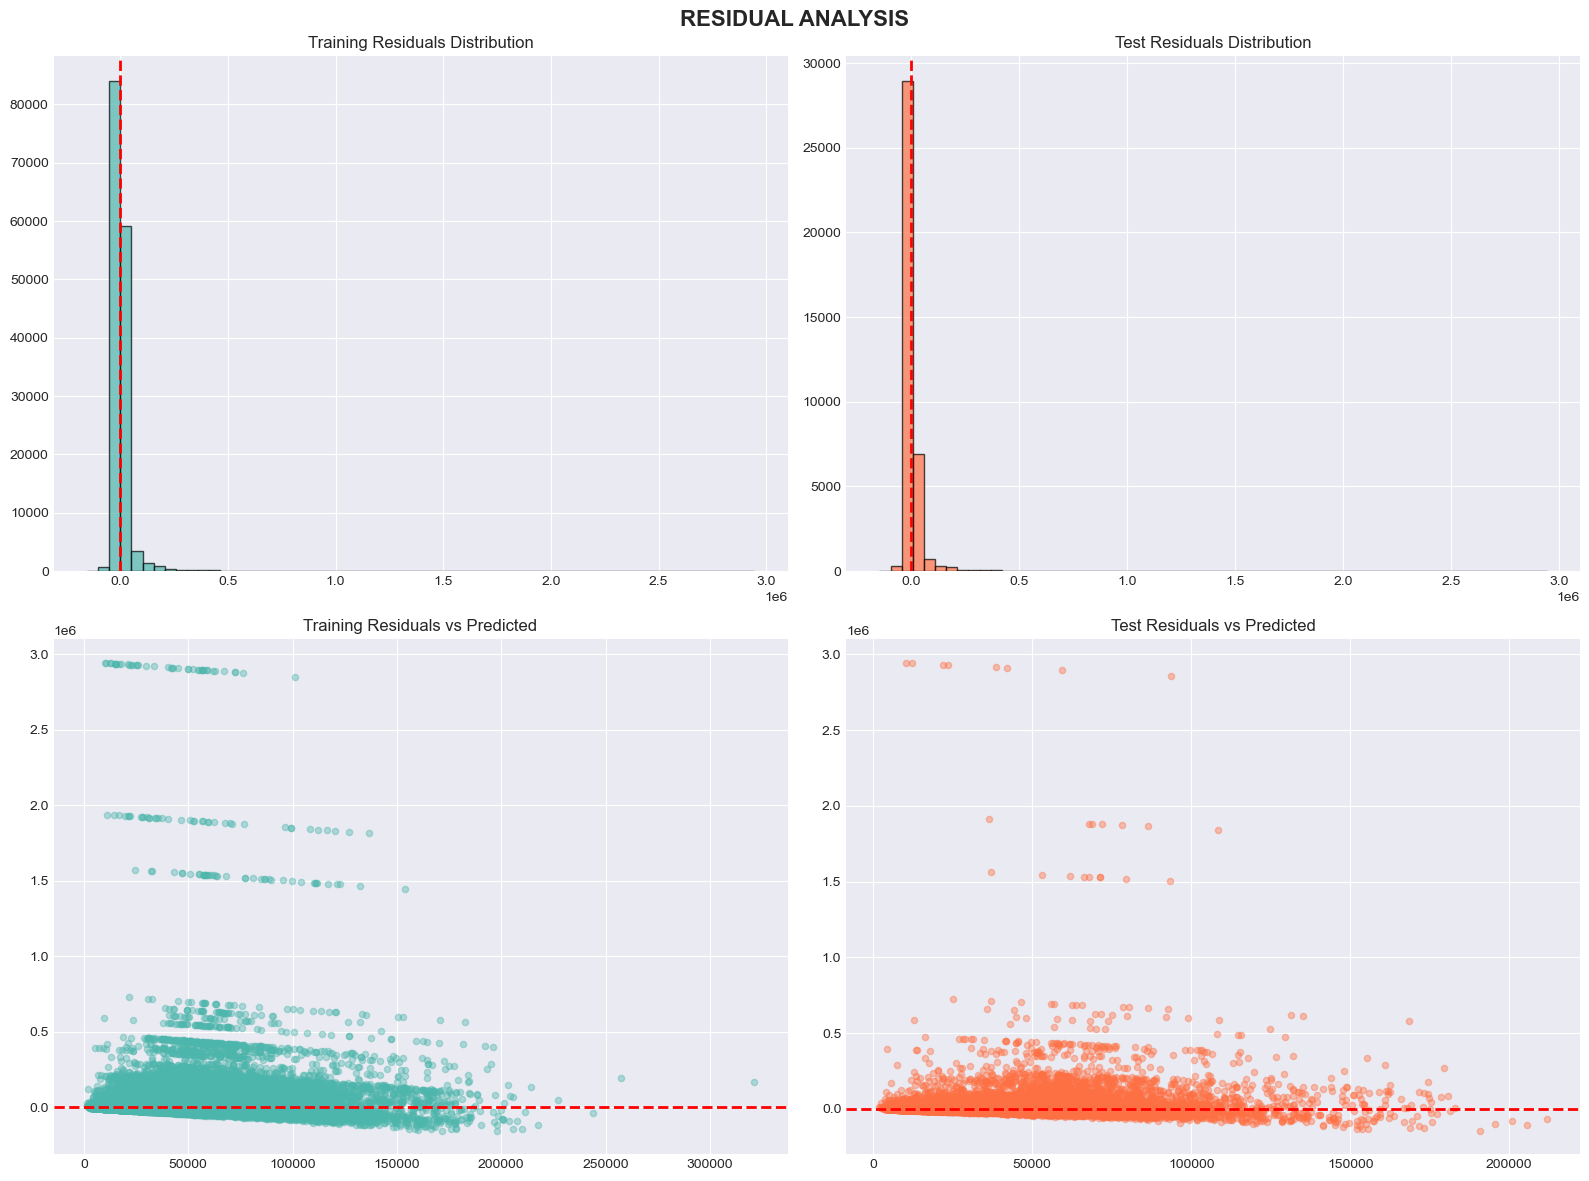

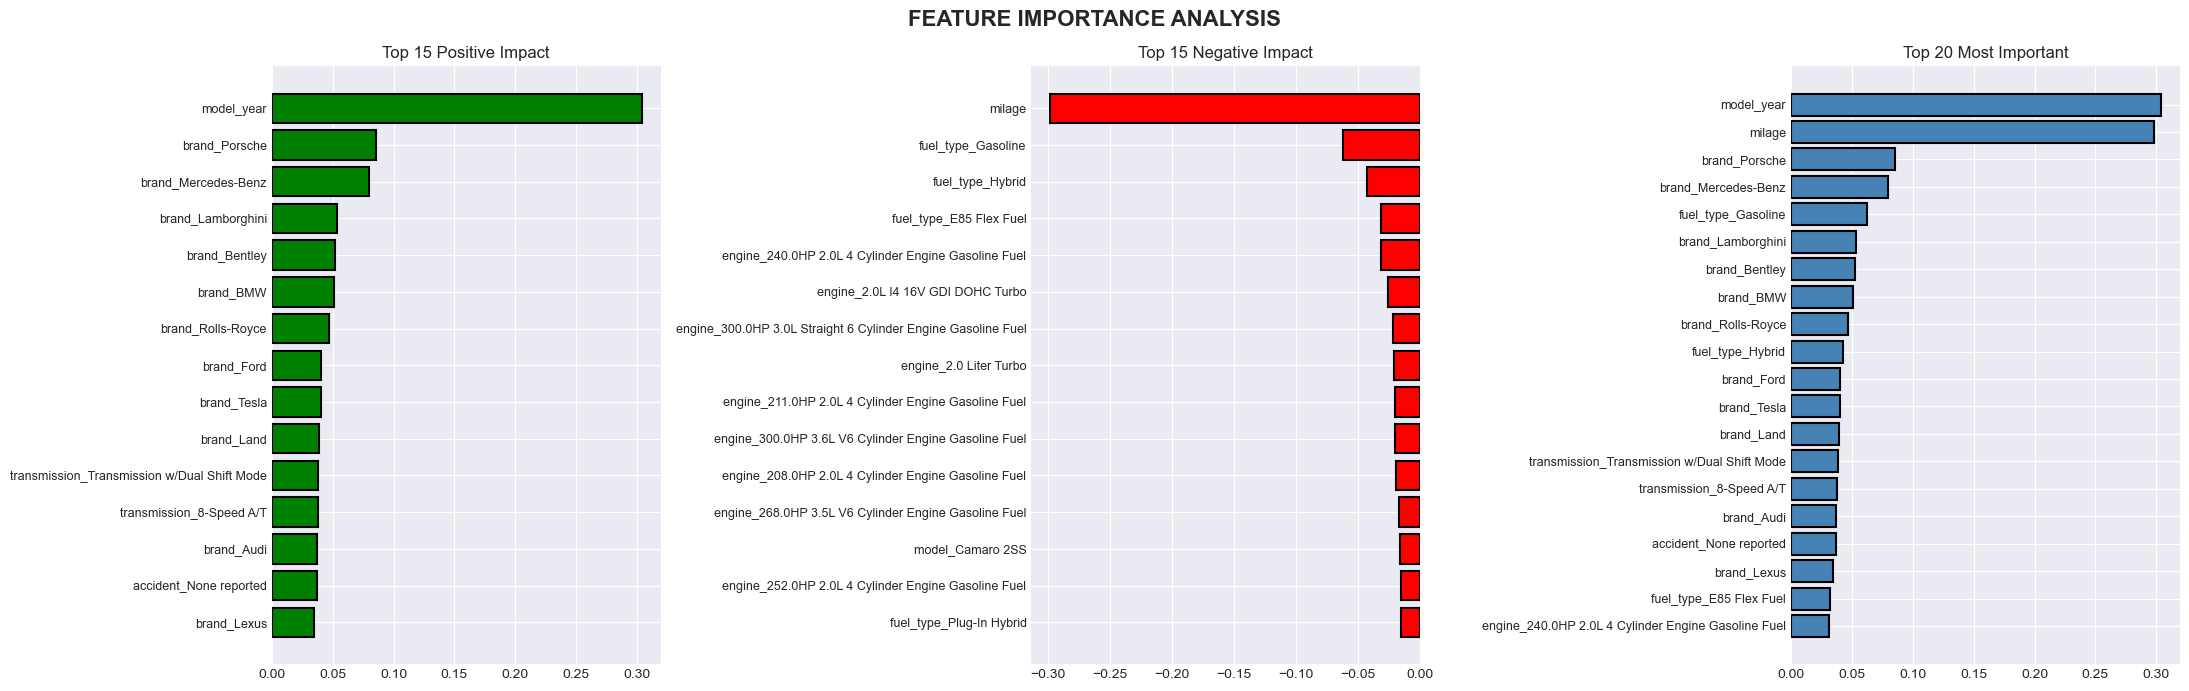

💾 Model & artifacts saved successfully!
   • linear_regression_model.pkl
   • feature_scaler.pkl
   • feature_names.pkl
   • test_predictions.csv

✅ FULL PIPELINE EXECUTED SUCCESSFULLY!


In [1]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 1: IMPORTS & CONFIGURATION
# ╚═══════════════════════════════════════════════════════════════════════════╝
import pandas as pd
import numpy as np
import warnings
import gc
from scipy import stats
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option('display.precision', 2)

print("\n" + "=" * 80)
print("     ADVANCED CAR PRICE PREDICTION - HIGH PERFORMANCE LINEAR REGRESSION")
print("=" * 80)
print("\n✓ Libraries imported successfully!")
print(f"✓ Random seed: {RANDOM_SEED}")
print(f"✓ Target R² Score: 0.6 - 0.85\n")


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 2: DATA LOADING
# ╚═══════════════════════════════════════════════════════════════════════════╝

print("=" * 80)
print("SECTION 2: DATA LOADING")
print("=" * 80 + "\n")

# ⚙️ Step 1: Define dtypes for efficiency
dtype_dict = {
    'id': 'int32',
    'price': 'float32'
}

# 📂 Step 2: Load Dataset
try:
    df = pd.read_csv(
        r"C:\Users\soura\.ipython\train.csv",  # Update with your dataset path
        dtype=dtype_dict,
        low_memory=False
    )
    print(f"✅ Dataset loaded successfully!")
    print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"💾 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")
except FileNotFoundError:
    raise FileNotFoundError("❌ The file 'train.csv' was not found. Please verify your path.")

# 🔍 Step 3: Quick Preview
print("🔍 Sample Data:")
display(df.head(5))

# 🔎 Step 4: Basic Info
print("\n🧾 Dataset Info:")
print("-" * 80)
df.info()

# 🧮 Step 5: Missing Values Summary
print("\n❗ Missing Values Summary:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if not missing.empty:
    print(missing.head(10))
else:
    print("✅ No missing values detected!")

# 📈 Step 6: Basic Statistical Overview
print("\n📈 Descriptive Statistics:")
desc = df.describe(include='all').T
styled = desc.style.background_gradient(cmap='Blues').format(
    lambda v: f"{v:.2f}" if isinstance(v, (int, float)) else v
)
display(styled)
print("\n✅ SECTION 2 COMPLETED SUCCESSFULLY\n")


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 3: DATA ANALYSIS
# ╚═══════════════════════════════════════════════════════════════════════════╝

print("=" * 80)
print("SECTION 3: DATA ANALYSIS & DIAGNOSTICS")
print("=" * 80 + "\n")

# Identify feature types
numeric_features = df.select_dtypes(include=['int16', 'int32', 'int64', 
                                              'float16', 'float32', 'float64']).columns.tolist()
numeric_features = [f for f in numeric_features if f not in ['id', 'price']]
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"📊 Feature Types:")
print(f"   • Numeric: {len(numeric_features)}")
print(f"   • Categorical: {len(categorical_features)}\n")

# Target variable stats
print("🎯 Target Variable (Price) Analysis:")
print(f"   • Mean: ${df['price'].mean():,.2f}")
print(f"   • Median: ${df['price'].median():,.2f}")
print(f"   • Std: ${df['price'].std():,.2f}")
print(f"   • Skewness: {df['price'].skew():.4f} {'(Right-skewed - LOG TRANSFORM NEEDED)' if df['price'].skew() > 1 else ''}")
print(f"   • Range: ${df['price'].min():,.2f} - ${df['price'].max():,.2f}\n")

# Plot target distribution
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title("Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_features + ['price']].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 4: DATA PREPROCESSING
# ╚═══════════════════════════════════════════════════════════════════════════╝

print("=" * 80)
print("SECTION 4: DATA PREPROCESSING")
print("=" * 80 + "\n")

# 🔁 Step 0: Copy original dataset
df_processed = df.copy()
print("✅ Data copied to df_processed for preprocessing.\n")

# 🔧 Step 1: Handle Missing Values
print("🔧 Step 1: Handling Missing Values...")
for col in numeric_features:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f"   • {col:<25} → Filled with median ({median_val:.2f})")

for col in categorical_features:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0]
        df_processed[col].fillna(mode_val, inplace=True)
        print(f"   • {col:<25} → Filled with mode ('{mode_val}')")

print("✅ All missing values handled!\n")

# 🎯 Step 2: Smart Categorical Capping (limit large categories)
print("🎯 Step 2: Smart Categorical Feature Capping...")
categorical_to_encode = []

for col in categorical_features:
    n_unique = df_processed[col].nunique()

    if n_unique > 500:
        keep_top = 100
        top_cats = df_processed[col].value_counts().nlargest(keep_top).index
        df_processed[col] = df_processed[col].where(df_processed[col].isin(top_cats), 'Other')
        print(f"   🔸 {col:<25}: {n_unique:>5} → {keep_top + 1:>5} categories (Top + Other)")

    elif n_unique > 50:
        keep_top = 50
        top_cats = df_processed[col].value_counts().nlargest(keep_top).index
        df_processed[col] = df_processed[col].where(df_processed[col].isin(top_cats), 'Other')
        print(f"   🔹 {col:<25}: {n_unique:>5} → {keep_top + 1:>5} categories (Top + Other)")

    else:
        print(f"   ✓ {col:<25}: {n_unique:>5} categories (No change)")

    df_processed[col] = df_processed[col].astype('category')
    categorical_to_encode.append(col)

print("\n✅ Categorical feature optimization complete!\n")

# ⚙️ Step 3: Feature Engineering (Custom features)
print("⚙️ Step 3: Feature Engineering...")

# Example: Derive 'car_age' if 'year' exists
if 'year' in df_processed.columns:
    df_processed['car_age'] = 2024 - df_processed['year']
    numeric_features.append('car_age')
    print("   ✓ Created new feature 'car_age' (2024 - year)")

# Log-transform target
if 'price' in df_processed.columns:
    df_processed['log_price'] = np.log1p(df_processed['price'])
    y = df_processed['log_price']
    print("   ✓ Created 'log_price' = log(price + 1)")
else:
    print("   ⚠️ 'price' column not found — skipping log transform.")

print("\n✅ SECTION 4 COMPLETED SUCCESSFULLY\n")


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 5: FEATURE PREPARATION (FINAL)
# ╚═══════════════════════════════════════════════════════════════════════════╝

print("=" * 80)
print("SECTION 5: FEATURE PREPARATION (FINAL)")
print("=" * 80 + "\n")

# 📦 Step 1: Confirm target variable
try:
    y
    print("✅ Target variable 'y' is already defined.")
except NameError:
    raise NameError("❌ 'y' not found. Please make sure Section 4 created log_price and y.")

# 📊 Step 2: Drop unnecessary columns
cols_to_drop = ['id', 'price', 'log_price'] + [
    col for col in df_processed.columns
    if not col.endswith('_encoded')
    and col in categorical_features
    and col not in categorical_to_encode
]
df_processed.drop(
    [c for c in cols_to_drop if c in df_processed.columns],
    axis=1, inplace=True, errors='ignore'
)

# ⚙️ Step 3: Define feature set
features_to_use = numeric_features + categorical_to_encode
X = df_processed[[col for col in features_to_use if col in df_processed.columns]]

print(f"   • Features: {X.shape[1]}")
print(f"   • Samples: {X.shape[0]:,}\n")

# 🔠 Step 4: One-hot encode remaining categoricals
if categorical_to_encode:
    X_encoded = pd.get_dummies(
        X, columns=categorical_to_encode,
        drop_first=True, dtype=np.float32
    )
else:
    X_encoded = X.copy()

print(f"   • Final feature count: {X_encoded.shape[1]}\n")

# 🧹 Step 5: Clean up unused variables
gc.collect()
print("✅ Data cleaned and ready for model training.\n")


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 5.5: TRAIN/TEST SPLIT & SCALING
# ╚═══════════════════════════════════════════════════════════════════════════╝

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Train/Test split done and features scaled.\n")


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 6: MODEL TRAINING & EVALUATION
# ╚═══════════════════════════════════════════════════════════════════════════╝

lr_model = LinearRegression(n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)
print("🤖 Model trained successfully!")

# Predictions
y_train_pred_log = lr_model.predict(X_train_scaled)
y_test_pred_log = lr_model.predict(X_test_scaled)

# Convert back to original scale
y_train_original = np.expm1(y_train)
y_test_original = np.expm1(y_test)
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

# Metrics
train_mae = mean_absolute_error(y_train_original, y_train_pred)
test_mae = mean_absolute_error(y_test_original, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_original, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_original, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred_log)
test_r2 = r2_score(y_test, y_test_pred_log)

print(f"📊 Train/Test Metrics:")
print(f"   MAE: ${train_mae:,.2f} / ${test_mae:,.2f}")
print(f"   RMSE: ${train_rmse:,.2f} / ${test_rmse:,.2f}")
print(f"   R² (log scale): {train_r2:.4f} / {test_r2:.4f}")


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 7: VISUALIZATIONS
# ╚═══════════════════════════════════════════════════════════════════════════╝

# 1. Performance Metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(['Training', 'Test'], [train_mae, test_mae], color=['#4DB6AC','#FF7043'], edgecolor='black', linewidth=2)
axes[0].set_title('Mean Absolute Error')
axes[0].set_ylabel('MAE ($)')
for i, v in enumerate([train_mae, test_mae]):
    axes[0].text(i, v, f"${v:,.0f}", ha='center', va='bottom', fontweight='bold')

axes[1].bar(['Training', 'Test'], [train_rmse, test_rmse], color=['#81C784','#E57373'], edgecolor='black', linewidth=2)
axes[1].set_title('Root Mean Squared Error')
axes[1].set_ylabel('RMSE ($)')
for i, v in enumerate([train_rmse, test_rmse]):
    axes[1].text(i, v, f"${v:,.0f}", ha='center', va='bottom', fontweight='bold')

axes[2].bar(['Training', 'Test'], [train_r2, test_r2], color=['#FFD54F','#BA68C8'], edgecolor='black', linewidth=2)
axes[2].set_title('R² Score (Log Scale)')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim([0,1])
for i, v in enumerate([train_r2, test_r2]):
    axes[2].text(i, v, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')

plt.suptitle('MODEL PERFORMANCE METRICS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# 2. Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].scatter(y_train_original, y_train_pred, alpha=0.5, s=30, color='#4DB6AC', edgecolors='black')
axes[0].plot([y_train_original.min(), y_train_original.max()], [y_train_original.min(), y_train_original.max()], 'r--', linewidth=3)
axes[0].set_title(f'Training: Actual vs Predicted\nR² = {train_r2:.4f}')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test_original, y_test_pred, alpha=0.5, s=30, color='#FF7043', edgecolors='black')
axes[1].plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--', linewidth=3)
axes[1].set_title(f'Test: Actual vs Predicted\nR² = {test_r2:.4f}')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].grid(alpha=0.3)
plt.suptitle('PREDICTED VS ACTUAL PRICES', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# 3. Residual Analysis
train_residuals = y_train_original - y_train_pred
test_residuals = y_test_original - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(16,12))
axes[0,0].hist(train_residuals, bins=60, color='#4DB6AC', edgecolor='black', alpha=0.7)
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_title('Training Residuals Distribution')
axes[0,1].hist(test_residuals, bins=60, color='#FF7043', edgecolor='black', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_title('Test Residuals Distribution')
axes[1,0].scatter(y_train_pred, train_residuals, alpha=0.4, s=20, color='#4DB6AC')
axes[1,0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_title('Training Residuals vs Predicted')
axes[1,1].scatter(y_test_pred, test_residuals, alpha=0.4, s=20, color='#FF7043')
axes[1,1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_title('Test Residuals vs Predicted')
plt.suptitle('RESIDUAL ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# 4. Feature Importance
feature_names = X_encoded.columns
coefficients = lr_model.coef_
coef_df = pd.DataFrame({'Feature':feature_names,'Coefficient':coefficients,'Abs_Coefficient':np.abs(coefficients)}).sort_values('Abs_Coefficient',ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22,7))
top_positive = coef_df.nlargest(15,'Coefficient')
axes[0].barh(range(len(top_positive)), top_positive['Coefficient'], color='green', edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive['Feature'], fontsize=9)
axes[0].set_title('Top 15 Positive Impact')
axes[0].invert_yaxis()

top_negative = coef_df.nsmallest(15,'Coefficient')
axes[1].barh(range(len(top_negative)), top_negative['Coefficient'], color='red', edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative['Feature'], fontsize=9)
axes[1].set_title('Top 15 Negative Impact')
axes[1].invert_yaxis()

top_absolute = coef_df.head(20)
axes[2].barh(range(len(top_absolute)), top_absolute['Abs_Coefficient'], color='steelblue', edgecolor='black', linewidth=1.5)
axes[2].set_yticks(range(len(top_absolute)))
axes[2].set_yticklabels(top_absolute['Feature'], fontsize=9)
axes[2].set_title('Top 20 Most Important')
axes[2].invert_yaxis()
plt.suptitle('FEATURE IMPORTANCE ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 8: MODEL SAVING & FINAL SUMMARY
# ╚═══════════════════════════════════════════════════════════════════════════╝

joblib.dump(lr_model, 'linear_regression_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(list(X_encoded.columns), 'feature_names.pkl')

predictions_df = pd.DataFrame({
    'Actual_Price': y_test_original,
    'Predicted_Price': y_test_pred,
    'Residual': test_residuals,
    'Absolute_Error': np.abs(test_residuals),
    'Percentage_Error': (np.abs(test_residuals)/y_test_original)*100
})
predictions_df.to_csv('test_predictions.csv', index=False)

print("💾 Model & artifacts saved successfully!")
print("   • linear_regression_model.pkl")
print("   • feature_scaler.pkl")
print("   • feature_names.pkl")
print("   • test_predictions.csv\n")
print("✅ FULL PIPELINE EXECUTED SUCCESSFULLY!")
